__Small Transcription Activating RNA (STAR) Simulations__

Alfred

In [8]:
# Libraries for mathematical analysis
import numpy as np
from skimage import measure
import sympy as sym
import pylab as pl
import matplotlib.pyplot as plt
import scipy.integrate
import biocircuits

# Libraries to visualize results
import bokeh.io
from bokeh.io import show
from bokeh.plotting import figure
from bokeh.plotting import column
import bokeh.palettes
from bokeh.models import LinearColorMapper, ColorBar
from bokeh.models import Range1d
from bokeh.io import export_svgs
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from bokeh.layouts import row

bokeh.io.output_notebook()

Loading BokehJS ...

<u>STAR Model</u>

![STAR Reaction Scheme](STAR_Reaction.png)

Model of a STAR system, where a small transcription activating RNA (STAR) binds to a paused trasncription elongation complex (target) to resume transcription. STARs can also bind a sequestering RNA that inhibits STAR from binding the target, forming a dsRNA complex.

The system is governed by the following equations:
\begin{align*}
&\dot{m} = \alpha_1 x_1 - \phi m - apm + dc - bzm + uq\\
&\dot{z} = \alpha_2 x_2 - \phi z - bzm + uq\\
&\dot{p} = dc - apm + vc\\
&\dot{c} = apm - dc - vc\\
&\dot{y} = vc - \phi y\\
&\dot{q} = bzm - uq - \phi q
\end{align*}

Where:
- $X_1 = \text{DNA Sequence/Plasmid for STAR}$
- $X_2 = \text{DNA Sequence/Plasmid for Sequestering RNA}$
- $M = \text{STAR}$
- $P = \text{Target RNA (Paused Transcription Elongation Complex)}$
- $C = \text{STAR-Target RNA Complex}$
- $Y = \text{Output mRNA}$
- $Z = \text{Sequestering RNA}$
- $Q = \text{Sequestered STAR}$

<u>Mathematically Derived Decision Boundaries & Activation Functions</u>

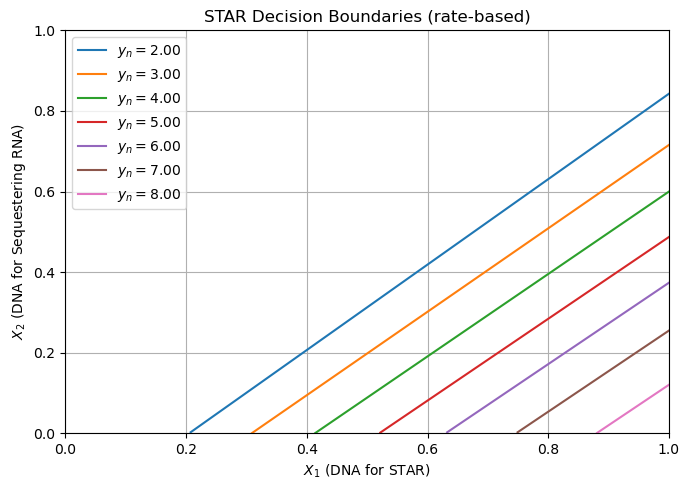

In [9]:
###Define Parameters
#Reaction rates
a   = 10.0   # STAR–target binding
d   = 1.0    # unbinding
v   = 1.0    # transcript release
b   = 100.0   # sequestration binding
u   = 0.2    # sequestration unbinding
phi = 0.1    # RNA decay

#DNA / Transcription scaling parameters
p_tot  = 1.0
alpha1 = 1.0
alpha2 = 1.0

#Other derived parameters
K1  = (d + v) / a
K2  = (u + phi) / b
tau = v / phi
xi  = K2 / K1
xi1 = phi * K1 / (v * p_tot)

#Define function for decision boundary
def starDecisionBoundary(beta1, y, tau, xi, xi1, p_tot):
    # If y > 1 --> Convert to normalized y_n
    y_n = y / p_tot if np.any(y > 1) else y
    
    # Decision boundary equation
    beta2 = (beta1 - xi1 * y_n / (tau - y_n) - y_n / tau) * (xi * tau + (1 - xi) * y_n) / y_n
    
    # Keep only physically possible values
    beta2[beta2 < 0] = np.nan
    beta2[y_n >= tau] = np.nan
    
    return beta2

###Plotting
#Define different y-values
yn_values = [0.2*tau, 0.3 * tau, 0.4 * tau, 0.5 * tau, 0.6*tau, 0.7*tau, 0.8 * tau] #Normalized
y_values = [y * p_tot for y in yn_values]  #Not normalized
beta1 = np.linspace(0.01, 3, 1000)

plt.figure(figsize=(7,5))

for y in yn_values:
    beta2 = starDecisionBoundary(beta1, y, tau, xi, xi1, p_tot)
    
    # Convert to DNA concentrations
    x1 = beta1 * v * p_tot / alpha1
    x2 = beta2 * v * p_tot / alpha2
    
    plt.plot(x1, x2, label=rf"$y_n={y:.2f}$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$X_1$ (DNA for STAR)")
plt.ylabel(r"$X_2$ (DNA for Sequestering RNA)")
plt.title("STAR Decision Boundaries (rate-based)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

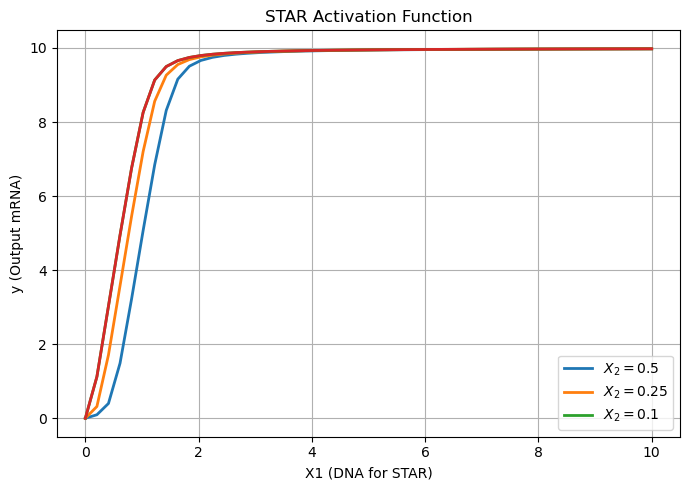

In [10]:
###Define Parameters
#Reaction rates
a   = 10.0    # input–target binding
d   = 1.0     # unbinding
v   = 1.0     # transcript processing / release
b   = 100.0   # sequestration binding
u   = 0.2     # sequestration unbinding
phi = 0.1    # RNA decay

#DNA / transcription scaling paramters
p_tot  = 1.0
alpha1 = 1.0
alpha2 = 1.0

#Other derived parameters
K1  = (d + v) / a
K2  = (u + phi) / b
tau = v / phi
xi  = K2 / K1
xi1 = phi * K1 / (v * p_tot)
beta1 = (alpha1 * x1) / (v * p_tot)
beta2 = (alpha2 * x2) / (v * p_tot)

###starActivationFunction() --> Defines the activation function and solves the polynomial for y
def starActivationFunction(x1, x2, xi, xi1, tau, alpha1, alpha2, v, p_tot):

    #Dimensionless inputs --> Need to define based on variable x1, x2
    beta1 = (alpha1 * x1) / (v * p_tot)
    beta2 = (alpha2 * x2) / (v * p_tot)

    #Define the cubic function for y
    A = (1 - xi)
    B = tau * (beta1*xi - beta1 + beta2 + xi*xi1 + 2*xi - xi1 - 1)
    C = tau**2 * (beta1 - 2*beta1*xi - beta2 - xi - xi*xi1)
    D = beta1 * xi * tau**3

    #Use numpy to solve roots
    roots = np.roots([A, B, C, D])
    realRoots = np.real(roots[np.isreal(roots)]) #Keep real roots only

    #Physical domain: 0 <= y_n <= tau
    valid = realRoots[(realRoots >= 0) & (realRoots <= tau)]

    if len(valid) == 0:
        y_n = 0.0
    else:
        # biologically relevant -> Largest admissible root
        y_n = np.max(valid)

    y = y_n * p_tot
    return y, y_n

###Plotting
#Define values for x1, x2
x2_vals = [0.5, 0.25, 0.1]
x1_vals = np.linspace(0, 10, 50)

plt.figure(figsize=(7,5))
for x2 in x2_vals:
    y_vals = []
    for x1 in x1_vals:
        y, y_n = starActivationFunction(x1, x2, xi, xi1, tau, alpha1, alpha2, v, p_tot)
        y_vals.append(y)

    y_vals = np.array(y_vals)
    plt.plot(x1_vals, y_vals, linewidth=2, label=rf"$X_2 = {x2}$")

plt.plot(x1_vals, y_vals, linewidth=2)
plt.xlabel("X1 (DNA for STAR)")
plt.ylabel("y (Output mRNA)")
plt.title("STAR Activation Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<u>Heatmap & Activation Functions</u>

In [11]:
# Function to do the 2D projection of decision boundaries with normalization <-- From the EBCP LATAM 2025 Workshop
def contourf(p, x, y, z, title=None, palette="Spectral11", normal = True):
    """Make a filled contour plot given x, y, z data given in 2D arrays."""

    # Normalize the z values
    if normal:
      z_min = z.min()
      z_max = z.max()
      z_normalized = (z - z_min) / (z_max - z_min)  # Normalize to range [0, 1]
    else:
      z_normalized = z

    # Add zero padding at the boundaries for better visualization
    N = z_normalized.shape[1]
    z0 = np.c_[z_normalized, np.zeros(N)]
    z0[-1, -1] = 1.  # Ensure the padding contains a value within range

    # Plot the normalized values
    p.image(
        image=[z0],
        x=x.min(),
        y=y.min(),
        dw=(x.max() - x.min()) * (1 + 1 / N),
        dh=x.max() - x.min(),
        palette=palette,
        alpha=0.8,
    )

    # Color mapping based on the normalized z0 values
    color = LinearColorMapper(palette=palette, low=z0.min(), high=z0.max())
    cb = ColorBar(color_mapper=color, location=(0, 0), width=10)
    p.add_layout(cb, 'right')

    return ()

In [12]:
#Function to help calculate the ODEs
#X --> Sets all concentrations to 0 at the start
def starODEs(X, t, alpha1, alpha2, rates):

    m, z, p, c, y, q = X

    #Unpack rates from array
    phi = rates["phi"] #Decay of RNA
    a = rates["a"] #Binding of STAR & target
    d = rates["d"] #Dissociation of STAR & target
    v = rates["v"] #Produciton of output
    b = rates["b"] #Binding of STAR & sequesterer
    u = rates["u"] #Dissociation of STAR & sequesterer

    #Write out the ODEs
    dm = alpha1 - phi*m - a*p*m + d*c - b*z*m + u*q
    dz = alpha2 - phi*z - b*z*m + u*q
    dp = d*c - a*p*m + v*c
    dc = a*p*m - d*c - v*c
    dy = v*c - phi*y
    dq = b*z*m - u*q - phi*q

    return [dm, dz, dp, dc, dy, dq]


In [47]:
# Define a grid of input values (x1, x2)
x1 = np.linspace(0, 1, 50)
x2 = np.linspace(0, 1, 50)
X1, X2 = np.meshgrid(x1, x2)

#Activation function inputs
x1Vals = np.linspace(0, 10, 50)
x2Vals = [3, 2, 1]

# Simulation time
t = np.linspace(0, 50, 1000)

#Initial species states
X0 = [0, 0, 0.5, 0, 0, 0] #[m, z, p, c, y, q]

#Weights for x1*alpha1 and x2*alpha2
w1 = 1
w2 = 1

#Kinetics parameters
ratesDefault = {
    'phi': np.array([0.1, 0.1, 0.1]),
    'a': np.array([10, 10, 10]),
    'd': np.array([0.1, 1, 10]),
    'v': np.array([1, 1, 1]),
    'b': np.array([100, 100, 100]),
    'u': np.array([0.2, 0.2, 0.2])
}

In [48]:
#getVariantRates() --> Extracts variant-specific rates from ratesDefault
def getVariantRates(ratesArray, variantIndex):
    rates = {}
    for key, arr in ratesArray.items():
        rates[key] = arr[variantIndex]
    return rates

numVariants = len(ratesDefault['phi']) #phi is in all models --> Best choice

#Bokeh color palette for heatmaps + activation functions
colors = bokeh.palettes.OrRd3

#Array to store all results
results = []

#Range through each variant --> Solve ODEs + Plot heatmap + Plot activation function --> Append to Results
for variantIndex in range(numVariants):
    #Get rates for this current iteration's variant
    rates = getVariantRates(ratesDefault, variantIndex)

    #ODE SOLUTIONS
    #Array for storing scipy.integrate solutions
    gridSolutions = [[None for _ in range(len(x1))] for _ in range(len(x2))]

    # Initialize a matrix to store the steady-state output y
    Y = np.zeros_like(X1)

    # Iterate over the grid values for all variable inputs X1 and X2 --> Solve the ODEs
    for i in range(len(x1)):
        for j in range(len(x2)):
            solutions = scipy.integrate.odeint(starODEs, X0, t, args=(w1 * X1[j, i], w2 * X2[j, i], rates))
            gridSolutions[j][i] = solutions
            Y[j, i] = solutions[-1, 4] #Extract the steady state output y

    #HEATMAPS
    p_heatmap = figure(width=350, height=300, title=f"Variant {variantIndex}")

    #Make the heatmap
    contourf(
        p_heatmap,
        X1,
        X2,
        Y,
        palette=bokeh.palettes.Oranges8[::-1],
        normal=True
    )

    p_heatmap.xaxis.axis_label = "X1 (STAR)"
    p_heatmap.yaxis.axis_label = "X2 (Sequestering RNA)"

    #ACTIVATION FUNCTIONS
    activationFunctions = {}
    p_activation = figure(width=350, height=300, title=f"Variant {variantIndex}")

    for x2j, color in zip(x2Vals, colors):

        curves = []
        output_y = np.zeros_like(x1Vals)

        for i, x1i in enumerate(x1Vals):

            sol = scipy.integrate.odeint(
                starODEs, X0, t,
                args=(w1 * x1i, w2 * x2j, rates)
            )

            curves.append(sol)
            output_y[i] = sol[-1, 4]

        activationFunctions[x2j] = curves

        p_activation.line(
            x1Vals,
            output_y,
            line_width=3,
            color=color,
            legend_label=f"X2 = {x2j}"
        )

    p_activation.xaxis.axis_label = "X1 (Input)"
    p_activation.yaxis.axis_label = "y (Output)"
    p_activation.legend.location = "top_left"

    #Append ODE solutions, heatmaps, and activation functions for all variants into the results array
    results.append({
        "variantIndex": variantIndex,
        "rates": rates,
        "solutions": {
            "grid": gridSolutions,
            "activation": activationFunctions
        },
        "heatmaps": p_heatmap,
        "activationFunctions": p_activation
    })

In [49]:
#Plot results
for res in results:
    print(f"\nVariant {res['variantIndex']}")
    for k, v in res["rates"].items():
        print(f"{k}: {v}")

    show(row(res["heatmaps"], res["activationFunctions"]))


Variant 0
phi: 0.1
a: 10
d: 0.1
v: 1
b: 100
u: 0.2



Variant 1
phi: 0.1
a: 10
d: 1.0
v: 1
b: 100
u: 0.2



Variant 2
phi: 0.1
a: 10
d: 10.0
v: 1
b: 100
u: 0.2


In [ ]:
#3D-Plot of the activation functions
fig = go.Figure(data=[
    go.Surface(z=Y, x=X1, y=X2, colorscale="Viridis")
])

fig.update_layout(
    scene=dict(
        xaxis_title='STAR (X1)',
        yaxis_title='Sequesterer RNA (X2)',
        zaxis_title='Ouput (Y)'
    ),
    width=800,
    height=600
)

fig.show()

<u>Stochastic Simulations</u>

In [ ]:
# Set up the stoichiometry matrix
starUpdate = np.array([
    #Columns: [M, Z, P, C, Y, Q]
    [ 1,  0,  0,  0,  0,  0],  # X1 -> X1 + M   (STAR transcription)
    [-1,  0,  0,  0,  0,  0],  # M -> 0         (STAR decay)
    [ 0,  1,  0,  0,  0,  0],  # X2 -> X2 + Z   (Sequesterer transcription)
    [ 0, -1,  0,  0,  0,  0],  # Z -> 0         (Sequesterer decay)
    [-1,  0, -1,  1,  0,  0],  # M + P -> C     (Target binding)
    [ 1,  0,  1, -1,  0,  0],  # C -> M + P     (Target unbinding)
    [ 0,  0,  1, -1,  1,  0],  # C -> P + Y     (Output production)
    [ 0,  0,  0,  0, -1,  0],  # Y -> 0         (Output decay)
    [-1, -1,  0,  0,  0,  1],  # M + Z -> Q     (Sequestration)
    [ 1,  1,  0,  0,  0, -1],  # Q -> M + Z     (Unsequestration)
    [ 0,  0,  0,  0,  0, -1],  # Q -> 0         (Sequestered complex decay)
])

In [ ]:
#Set up the propensity matrix for each reaction --> Represents the probabilities that each chemical reaction will occur at a given point in time
def starPropensity(propensities, population, t, alpha1, alpha2, a, d, b, u, v, phi, omega):
    M, Z, P, C, Y, Q = population

    # Transcription --> Needs to be scaled by cell volume Omega
    propensities[0] = alpha1 * omega    #X1 --> X1 + M
    propensities[1] = phi * M           #M --> 0
    propensities[2] = alpha2 * omega    #X2 --> X2 + Z
    propensities[3] = phi * Z           #Z --> 0

    # STAR-Target binding/unbinding & Output production
    propensities[4] = a * M * P        # M + P -> C
    propensities[5] = d * C             # C -> M + P
    propensities[6] = (v * C)           # C -> P + Y
    propensities[7] = phi * Y           # Y -> 0

    # STAR-Sequestration
    propensities[8] = (b * M * Z)/omega         # M + Z -> Q
    propensities[9] = u * Q             # Q -> M + Z
    propensities[10] = phi * Q          # Q -> 0

In [ ]:
# Define kinetic parameters
ratesStochastic = {
    "alpha1": 0.5,  # STAR transcription
    "alpha2": 0.3,  # Sequesterer transcription
    'phi': 0.1,     # RNA decay
    'a': 1.0,       # M + P binding
    'd': 0.05,      # M-P unbinding
    'v': 1.0,       # Output production
    'b': 1.0,       # M + Z binding
    'u': 0.05       # M-Z unbinding
}

# Conversion factor to molecule numbers
omega = 600 #From the workshop --> E. coli cell volume

# Time points
timePoints = np.linspace(0, 80, 801)

# Initial conditions: M, Z, P, C, Y, Q
populationAt0 = np.array([0, 0, 1, 0, 0, 0]) #All start at zero, except P --> Assume targets already exist in system

#Turn kinetics into a tuple
argsStar = (ratesStochastic["alpha1"], ratesStochastic["alpha2"], ratesStochastic["a"], ratesStochastic["d"], ratesStochastic["b"], ratesStochastic["u"], ratesStochastic["v"], ratesStochastic["phi"], omega)

In [ ]:
samples = biocircuits.gillespie_ssa(
    starPropensity,
    starUpdate,
    populationAt0,
    timePoints,
    size=20,
    args=argsStar,
    n_threads=2,
    progress_bar=True
)

# Save results
np.save("STAR_stochastic.npy", samples)

100%|██████████| 20/20 [01:00<00:00,  3.03s/it]
/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py:301: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-jk2yjxsb'}
  warnings.warn(


In [ ]:
fig_size = [320, 250]
plots = []

# Create figure for M, Z, P, C, Y, Q
species_labels = ['M (STAR)', 'Z (Sequestering RNA)', 'P (Target RNA)',
                  'C (Complex M-P)', 'Y (Output mRNA)', 'Q (Sequestered STAR)']

for i in range(6):
    plots.append(bokeh.plotting.figure(width=fig_size[0], height=fig_size[1],
                                       x_axis_label='Time (hours)',
                                       y_axis_label='Molecule count'))

for traj in range(len(samples)):
    for i in range(6):
        color = bokeh.palettes.Category10[6][i]
        plots[i].line(timePoints, samples[traj,:,i], line_width=2, color=color, legend_label=species_labels[i])

for p in plots:
    p.legend.location = 'bottom_right'

bokeh.io.show(bokeh.layouts.column(*plots))